1. Bigram tokenization and change of basis 
2. Notes on reconstruction 
3. Byte Pair Encoding
4. Python Prototyping
5. C++ considerations
6. Token sets on individual docs vs an aggregated set. 
On that last one, write a python script that calls these c++ executables in parallel processes and aggregates the token sets after... 

# Bigram tokenization and change of basis 
Goal here is to explore the bigram tokenizer, and see if there's anything interesting that comes from running an fft on it. Trying it out with an FFT first, but the token sequences are not periodic and have high frequency jumps -- spaces are token 32 so they make all these jagged jumps in the text signal. Embeddings might be something to add between the tokenizer and fft step so see if it does anything interesting -- bert. 

ok but here, we just want to get a feel for what happens to even small changes on the token sequence in another domain -- why is this important? all matrices operating on the input vector are basically changes of basis... put the compressed sensing thing here --> its a stack of those. so if we know what something like fft does to the token sequence we might learn something about what the network is doing.... need to think about this more. 

In [5]:
!python py_versions/Word_decomp.py

tokenizer obj info
n_gram: bigram
charset:  !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}
vocabulary_size: 8836

Encoding and decoding text

Original text 
FYODOR MIKHAILOVITCH DOSTOEVSKY was born at Moscow on October 30, 1821, the son of a military surgeon. He was educated in his native city and at the School of Military Engineering at St. Petersburg, from which he graduated in 1843 with the grade of sub-lie

Reconstruction 
FYODOR MIKHAILOVITCH DOSTOEVSKY was born at Moscow on October 30, 1821, the son of a military surgeon. He was educated in his native city and at the School of Military Engineering at St. Petersburg, from which he graduated in 1843 with the grade of sub-lie
(2298, 256)
Result of FFT followed by iFFT - real
FYODOR MIKHAILOVITCH DOSTOEVSKY was born at Moscow on October 30, 1821, the son of a military surgeon. He was educated in his native city and at the School of Military Engineering at St. Petersburg, from which he gr

# Notes on text reconstruction and fft plots of the token sequences 



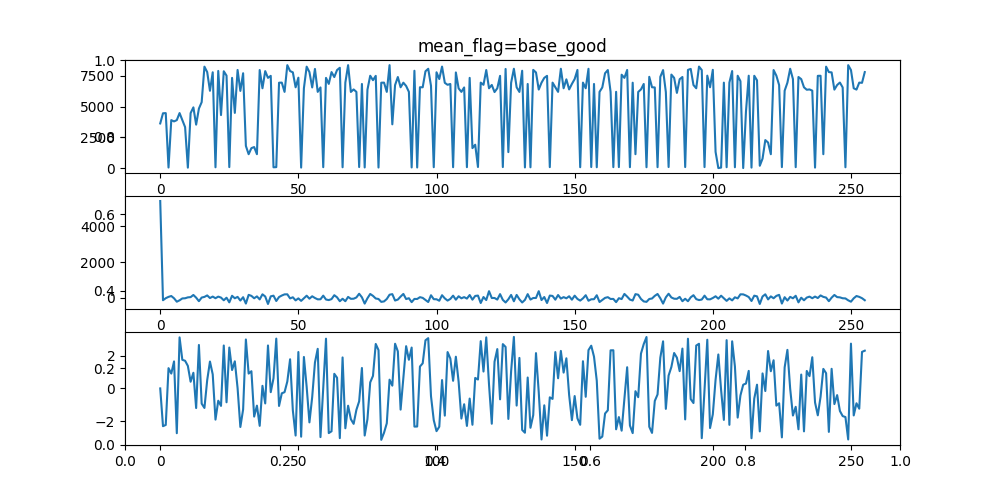

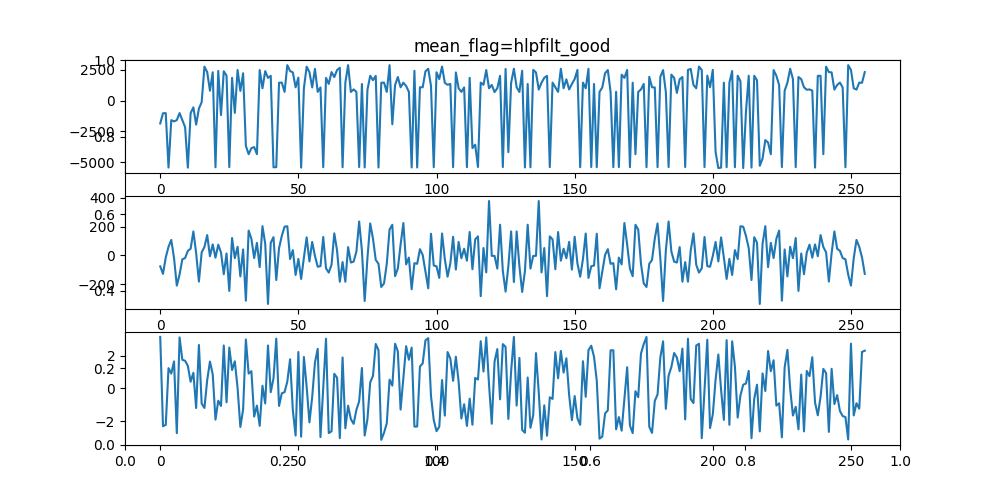

In [6]:
from PIL import Image 
# show the token signal and the fft, etc
img = Image.open('imgs/signals_base_good.png')
img.show()

img = Image.open('imgs/signals_hlpfilt_good.png')
img.show()



# Byte Pair Encoding 
https://en.wikipedia.org/wiki/Byte-pair_encoding
The algorithm sounds straight forward, just count all the pairs and merge top pairs till you end up with some nice sequences you can use to represent the text. great. 

in practice what do we end up having to build? a lot... and this version is still slower than using a few arrays... either way this one is a bit more intuitive to think about. 

the whole argument behind using arrays; using the doubly you scatter a bunch of pointers in ram instead of having this contiguous memory block, and you end up getting cache misses. plus you spend a lot of time destroying old nodes. 


## Python prototyping
Prototyped it out in Python first, then implemented in C++ 
1. Doubly linked list to handle the text sequence - avoids having to make a new list on every itteration
2. Doubly linked list is really a Node Class where we can point to next and previous node -- but also we store the value and store the sequences of interest... Then a Chain Class to start a head node, make the subsequent nodes on initialization and get an initial count -- **this count does not change! it is static!** so that means we only need to count once - count, sort, and make a priority queue
4. Update logic as a part of the chain class - do not recount, use a while loop and make sure you swap nodes and manually increment and decrement the counters. if you have to do a recount then it becomes O(N^2). when you swap a node out, then push a new pair to the heapq -- python uses a min heap so we store (-) frequency to get the top pair in O(1) time. When we find the best pair we also pop any pairs from the heap to keep it clean
5. then we have functions for dumping the token set to json. and then some other code for timing

**Scroll to the bottom of the next block for the timing. The script prints the token set before printing the timing info**


In [33]:
!python py_versions/pytok5_links.py

init text lenght  1171247
initial token set  {10, 32, 33, 34, 38, 39, 40, 41, 42, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 128, 134, 145, 147, 148, 160, 164, 166, 167, 168, 169, 170, 174, 175, 180, 182, 188, 195, 197, 226}
len initial set  99

--- FINAL VOCABULARY ---
(63,) -> '?'
(104, 101, 32, 119, 97, 115, 32) -> 'he was '
(116, 104, 101, 109, 32) -> 'them '
(100, 114, 105) -> 'dri'
(112, 101, 99) -> 'pec'
(111, 110) -> 'on'
(97, 108, 108, 32) -> 'all '
(166,) -> [Partial Multi-byte Sequence]
(111, 119) -> 'ow'
(101, 108, 108) -> 'ell'
(105, 116, 99, 104) -> 'itch'
(114, 105, 101, 100, 32) -> 'ried '
(111, 115, 116, 32) -> 'ost '
(116, 115, 32) -> 'ts '
(40,) -> '('
(59, 32) -> '; '
(108, 101, 44, 32) -> 'le, '
(49,) -> '1'
(

# C++ considerations 
So basially make the same algorithm to be able to compare. 
use 
1. unordered_map with the hashing function
2. also uses priority queue from queue
3. build with the -O23 flag to make it fast


**Scroll to the bottom of each section for timing - also the make file doesnt clean, so be aware of that**

In [30]:
!make -C cpp_versions build-all

make: Entering directory '/mnt/g/TokenizerThoughts/cpp_versions'
Compling tok chain
g++ -std=c++20  ./tok_chain2.cpp -o ./tok_chain.exe 
base verion built
Compling tok chain fast
g++ -std=c++20 -O3 ./tok_chain2.cpp -o ./tok_chain_fast.exe 
fast verion built
make: Leaving directory '/mnt/g/TokenizerThoughts/cpp_versions'


In [31]:
!./cpp_versions/tok_chain.exe


--- Unique Sequences Found (607) ---
[
]
[

]
[

"]
[ ]
[ a]
[ a ]
[ a m]
[ a s]
[ ab]
[ about ]
[ ac]
[ af]
[ ag]
[ again]
[ al]
[ all]
[ all ]
[ am]
[ an]
[ an ]
[ and]
[ and ]
[ ar]
[ are ]
[ as]
[ as ]
[ at]
[ at ]
[ at the ]
[ c]
[ con]
[ h]
[ ha]
[ had ]
[ have ]
[ he ]
[ her]
[ her ]
[ him]
[ his ]
[ in]
[ m]
[ my ]
[ s]
[ sa]
[ se]
[ she ]
[ t]
[ th]
[ that]
[ that ]
[ that he ]
[ the]
[ the ]
[ the s]
[ them]
[ then]
[ there ]
[ they ]
[ this ]
[ though]
[ tim]
[ to]
[ to ]
[ to the ]
[ too]
[ tr]
[ tw]
[ w]
[ wh]
[ with]
[!]
[! ]
["]
["

]
["

"]
[" ]
[&]
[']
['s]
['s ]
['t ]
[(]
[)]
[*]
[,]
[, ]
[, and]
[, and ]
[, b]
[, but ]
[, he ]
[, s]
[, the ]
[, wh]
[,"]
[," ]
[," he ]
[-]
[.]
[.

]
[.

"]
[. ]
[. "]
[. . ]
[. . .]
[. . . ]
[. . . . ]
[. A]
[. He ]
[. I]
[. S]
[. She ]
[. T]
[. The ]
[."

]
[."

"]
[0]
[1]
[2]
[3]
[4]
[5]
[6]
[7]
[8]
[9]
[:]
[;]
[; ]
[?]
[? ]
[?"]
[?"

"]
[A]
[An]
[And ]
[B]
[But ]
[C]
[D]
[Doun]
[Dounia]
[E]
[F]
[G]
[H]
[He ]
[I]
[I ]
[I am]
[I s]
[

In [32]:
!./cpp_versions/tok_chain_fast.exe


--- Unique Sequences Found (607) ---
[
]
[

]
[

"]
[ ]
[ a]
[ a ]
[ a m]
[ a s]
[ ab]
[ about ]
[ ac]
[ af]
[ ag]
[ again]
[ al]
[ all]
[ all ]
[ am]
[ an]
[ an ]
[ and]
[ and ]
[ ar]
[ are ]
[ as]
[ as ]
[ at]
[ at ]
[ at the ]
[ c]
[ con]
[ h]
[ ha]
[ had ]
[ have ]
[ he ]
[ her]
[ her ]
[ him]
[ his ]
[ in]
[ m]
[ my ]
[ s]
[ sa]
[ se]
[ she ]
[ t]
[ th]
[ that]
[ that ]
[ that he ]
[ the]
[ the ]
[ the s]
[ them]
[ then]
[ there ]
[ they ]
[ this ]
[ though]
[ tim]
[ to]
[ to ]
[ to the ]
[ too]
[ tr]
[ tw]
[ w]
[ wh]
[ with]
[!]
[! ]
["]
["

]
["

"]
[" ]
[&]
[']
['s]
['s ]
['t ]
[(]
[)]
[*]
[,]
[, ]
[, and]
[, and ]
[, b]
[, but ]
[, he ]
[, s]
[, the ]
[, wh]
[,"]
[," ]
[," he ]
[-]
[.]
[.

]
[.

"]
[. ]
[. "]
[. . ]
[. . .]
[. . . ]
[. . . . ]
[. A]
[. He ]
[. I]
[. S]
[. She ]
[. T]
[. The ]
[."

]
[."

"]
[0]
[1]
[2]
[3]
[4]
[5]
[6]
[7]
[8]
[9]
[:]
[;]
[; ]
[?]
[? ]
[?"]
[?"

"]
[A]
[An]
[And ]
[B]
[But ]
[C]
[D]
[Doun]
[Dounia]
[E]
[F]
[G]
[H]
[He ]
[I]
[I ]
[I am]
[I s]
[

...we need the array implementation to work on large corpora -> 1.7MB @ 5s --> 3.4 million tokens per second is not good enough hm . actually. at 1.47billion (e9) words... say...x3 - looking at 1297s or about a half an hour to tokenize something like 18GB of text.... but I havent evaluated this algorithm for long runs. Need to test array logic. 